# Crop Yield Prediction — Linear Regression
**Mission:** Help smallholder farmers plan fertilizer and irrigation decisions by predicting crop yield (tons/hectare) from environmental and farming-practice data.

**Dataset:** [Agriculture Crop Yield](https://www.kaggle.com/datasets/samuelotiattakorah/agriculture-crop-yield) — 1,000,000 rows, mix of categorical and numeric features.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

df = pd.read_csv('crop_yield.csv')
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


## Exploratory Data Analysis

In [26]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  str    
 1   Soil_Type               1000000 non-null  str    
 2   Crop                    1000000 non-null  str    
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  str    
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), str(4)
memory usage: 62.9 MB


,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


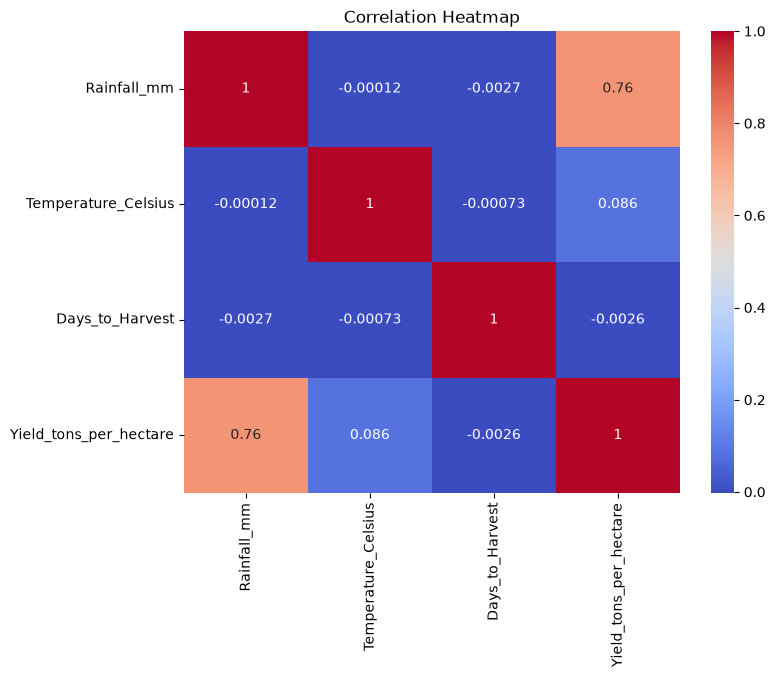

In [27]:
# Correlation heatmap (numeric features only)
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Interpretation:** [Fill in after running — e.g. "Rainfall_mm and Days_to_Harvest show the strongest correlation with Yield_tons_per_hectare, suggesting they'll carry the most predictive weight."]

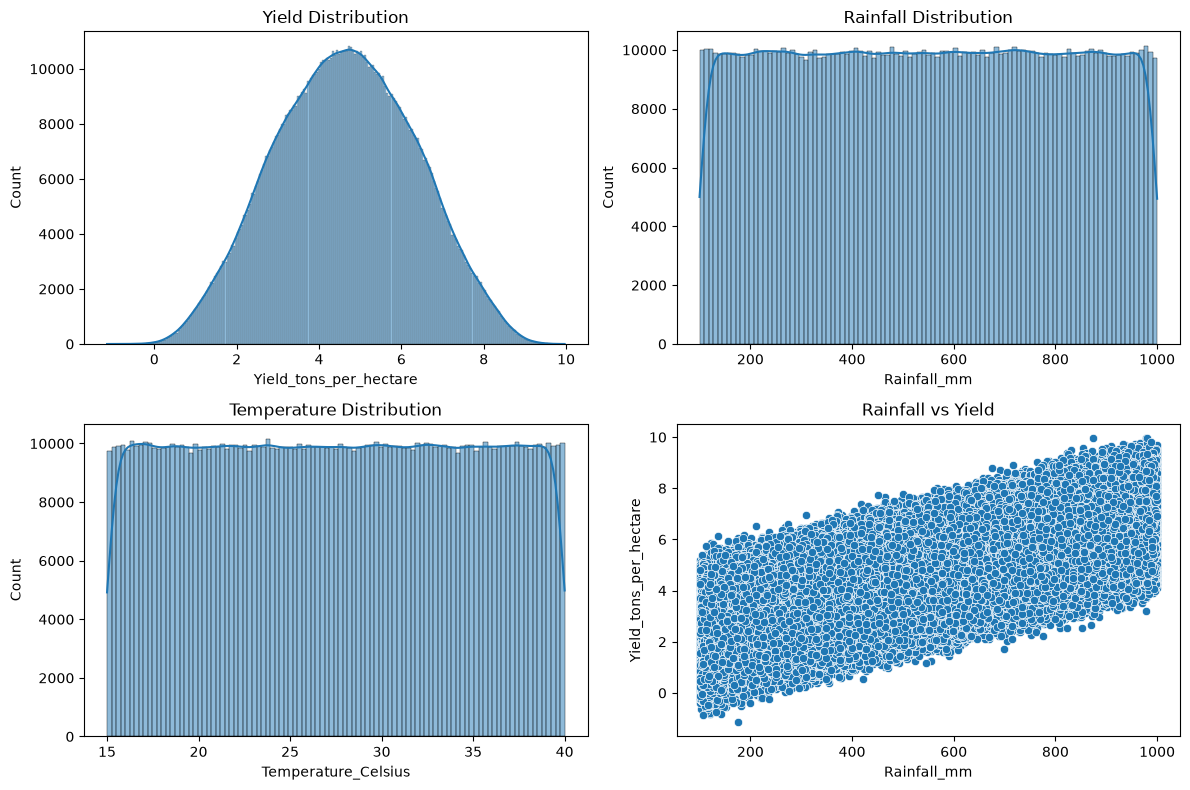

In [28]:
# Distribution of target and key numeric features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['Yield_tons_per_hectare'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Yield Distribution')
sns.histplot(df['Rainfall_mm'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Rainfall Distribution')
sns.histplot(df['Temperature_Celsius'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Temperature Distribution')
sns.scatterplot(x='Rainfall_mm', y='Yield_tons_per_hectare', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Rainfall vs Yield')
plt.tight_layout()
plt.show()

**Interpretation:** [Fill in — note skew, outliers, whether rainfall/yield relationship looks linear.]

## Feature Engineering

In [29]:
# Boolean columns -> 0/1
df['Fertilizer_Used'] = df['Fertilizer_Used'].astype(int)
df['Irrigation_Used'] = df['Irrigation_Used'].astype(int)

# Categorical columns that need encoding: Region, Soil_Type, Crop, Weather_Condition
categorical_cols = ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']
numeric_cols_x = ['Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used',
                   'Irrigation_Used', 'Days_to_Harvest']

# No columns dropped here — all 9 features plausibly affect yield.
# If correlation heatmap shows a numeric feature near-zero correlation, drop it before training.

X = df[categorical_cols + numeric_cols_x]
y = df['Yield_tons_per_hectare']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# Standardize numeric features, one-hot encode categorical features
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols_x),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

## Model Training & Comparison
Stochastic linear regression (SGD) vs. ordinary least squares Linear Regression, Decision Tree, and Random Forest.

In [31]:
# Subsample for faster iteration (1M rows is overkill for training time here)
sample_size = 200000
sample_idx = np.random.RandomState(42).choice(X_train_proc.shape[0], size=sample_size, replace=False)
X_train_sample = X_train_proc[sample_idx]
y_train_sample = y_train.iloc[sample_idx]

models = {
    'SGD Linear Regression (stochastic)': SGDRegressor(max_iter=1000, tol=1e-3, random_state=42),
    'Linear Regression (OLS)': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sample, y_train_sample)
    preds = model.predict(X_test_proc)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results[name] = {'model': model, 'mse': mse, 'r2': r2}
    print(f'{name}: MSE={mse:.4f}, R2={r2:.4f}')

SGD Linear Regression (stochastic): MSE=0.2516, R2=0.9127
Linear Regression (OLS): MSE=0.2508, R2=0.9130
Decision Tree: MSE=0.5287, R2=0.8166
Random Forest: MSE=0.2709, R2=0.9060


In [32]:
best_name = min(results, key=lambda k: results[k]['mse'])
best_model = results[best_name]['model']
print(f'Best model: {best_name} (MSE={results[best_name]["mse"]:.4f})')

Best model: Linear Regression (OLS) (MSE=0.2508)


## Loss Curve (SGD model, train vs test)

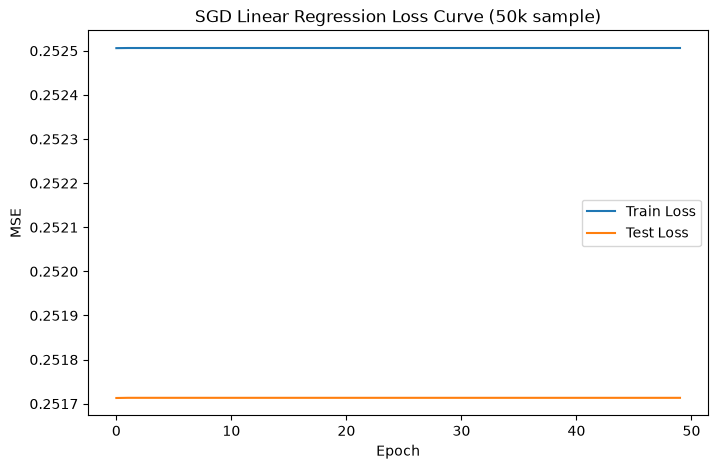

In [33]:
# Use a subsample for speed - still demonstrates the loss trend clearly
n_sample = 50000
rng = np.random.RandomState(42)
idx = rng.choice(X_train_proc.shape[0], size=n_sample, replace=False)
X_sub = X_train_proc[idx]
y_sub = y_train.iloc[idx]

sgd = SGDRegressor(max_iter=1, tol=None, warm_start=True, random_state=42)
train_losses, test_losses = [], []
n_epochs = 50

for epoch in range(n_epochs):
    sgd.fit(X_sub, y_sub)
    train_losses.append(mean_squared_error(y_sub, sgd.predict(X_sub)))
    test_losses.append(mean_squared_error(y_test, sgd.predict(X_test_proc)))

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('SGD Linear Regression Loss Curve (50k sample)')
plt.legend()
plt.show()

## Scatter Plot: Best-Fit Line (single strongest feature vs yield)

Feature used for line plot: Rainfall_mm


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


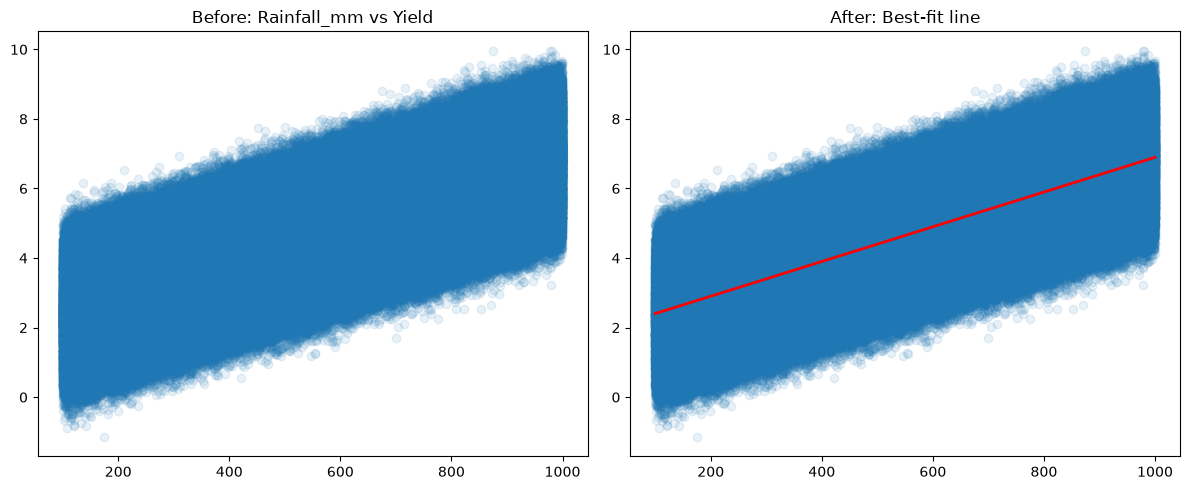

In [34]:
# Use the numeric feature most correlated with yield for a 2D visualization
best_feature = df[numeric_cols_x + ['Yield_tons_per_hectare']].corr()['Yield_tons_per_hectare'].drop('Yield_tons_per_hectare').abs().idxmax()
print('Feature used for line plot:', best_feature)

lr_simple = LinearRegression()
lr_simple.fit(df[[best_feature]], df['Yield_tons_per_hectare'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df[best_feature], df['Yield_tons_per_hectare'], alpha=0.1)
axes[0].set_title(f'Before: {best_feature} vs Yield')

axes[1].scatter(df[best_feature], df['Yield_tons_per_hectare'], alpha=0.1)
x_line = np.linspace(df[best_feature].min(), df[best_feature].max(), 100)
y_line = lr_simple.predict(x_line.reshape(-1, 1))
axes[1].plot(x_line, y_line, color='red', linewidth=2)
axes[1].set_title(f'After: Best-fit line')
plt.tight_layout()
plt.show()

## Save Best Model

In [35]:
joblib.dump(best_model, '../API/best_model.pkl')
joblib.dump(preprocessor, '../API/preprocessor.pkl')
print('Saved:', best_name)

Saved: Linear Regression (OLS)


## Prediction on a Single Test Row (feeds into Task 2)

In [36]:
sample_row = X_test.iloc[[0]]
sample_proc = preprocessor.transform(sample_row)
prediction = best_model.predict(sample_proc)
print('Sample input:\n', sample_row)
print('Predicted yield:', prediction[0])
print('Actual yield:', y_test.iloc[0])

Sample input:
        Region Soil_Type    Crop Weather_Condition  Rainfall_mm  \
987231   West      Silt  Cotton             Sunny   714.854403   

        Temperature_Celsius  Fertilizer_Used  Irrigation_Used  Days_to_Harvest  
987231            23.875872                0                0              120  
Predicted yield: 4.042656758091837
Actual yield: 3.8409878810017286
